## 1. Title + Paper you replicate + Research question

## 2. Data

### 2.1 Data Source

The data I'm using for this analysis come from the Integrated Public Use Microdata Series (IPUMS) Current Population Survey (CPS) and the Annual Social and Economic Supplements (ASEC). The CPS is a nationally representative household survey conducted by the U.S. Census Bureau, and the ASEC supplement provides detailed information on labor market outcomes, income, and demographic characteristics. Both datasets are suitable for my project in analyzing the labor supply effects of the 1986 Tax Reform Act.

### 2.2 Sample Construction

The sample is restricted to women aged 18 to 55, focusing on prime working-age individuals. Restricting the sample avoids the confounding effect from retirement or school enrollment and ensures comparability with the original Eissa(1996) Study

The final estimate sample contains 1,397,610 observations after applying the restriction



In [1]:
import pandas as pd
import numpy as np

cols = [
    "YEAR",
    "AGE",
    "SEX",
    "MARST",
    "EMPSTAT",
    "INCWAGE",
    "EDUC",
    "NCHILD",
    "ASECWT"
]

df = pd.read_csv(
    "data/cps_00001.csv.gz",
    usecols=cols,
    compression="gzip"
)

df.head()

,YEAR,ASECWT,AGE,SEX,MARST,NCHILD,EMPSTAT,EDUC,INCWAGE
0,1984,568.47,43,1,1,1,10,40,16200.0
1,1984,568.47,41,2,1,1,10,72,9300.0
2,1984,616.15,20,1,6,0,10,72,7360.0
3,1984,568.47,42,1,1,1,10,72,18150.0
4,1984,568.47,41,2,1,1,31,72,0.0


In [2]:
df.shape

(5831879, 9)

This tells us that in the data, there's 5,831,879 rows and 9 columns. However, as we're only measuring the labor supply of married women, our treated group will be marreid women which I'll restrict the sample to females that is age 18-55.

In [3]:
# Keep only females
df = df[df["SEX"] == 2]

# Keep working age women
df = df[(df["AGE"] >= 18) & (df["AGE"] <= 55)]

df.shape

(1397610, 9)

This has shrink our data from 5,831,879 observations to only 1,397,610 observations now.

### 2.3 Variable Construction

The main outcome variable, employed, is an indicator equal to 1 if the individual is at work or has a job but is temporarily absent, and 0 otherwise. This follows the standard CPS employment classification and aligns with the labor supply measure used in the original paper.

The treatment indicator, treated, equals 1 for married women and 0 otherwise. Married women constitute the treatment group because the 1986 Tax Reform Act reduced marginal tax rates, affecting secondary earners in married households.

The post-treatment indicator, post, equals 1 for years 1987 and later, corresponding to the period after the reform was implemented.

The interaction between the treated and post will capture the Difference-in-Differences effect.

In [4]:
df["post"] = (df["YEAR"] >= 1987).astype(int)
df["treated"] = (df["MARST"] == 1).astype(int)
df["employed"] = df["EMPSTAT"].isin([10, 12]).astype(int)
df = df[df["INCWAGE"] > 0]
df["log_wage"] = np.log(df["INCWAGE"])
df[["treated", "post", "employed"]].mean()

treated     0.570600
post        0.574483
employed    0.848697
dtype: float64

...

## 3. Identification (DiD assumptions + parallel trends)

### 3.1 Treatment and Control Groups

The identification strategy had exploits the differential impact of the 1986 Tax Reform Act on married versus single women. The reform had reduced marginal tax rates in a way that primarily affected secondary earners in married households, and as married women are more likely to be secondary earners, they experienced a larger change in the labor supply incentives.

Married women therefore constitute the treatment groups, while single women serve as the control group. The post treatment begin in 1987 follow by the implementation of the tax reform.

The Difference in Differences framework compares the change in employment outcomes for married women before and after the reform to the corresponding change for single women over the same period as well.

### 3.2 Parallel Trends Assumption

The key identifying assumption of the Difference-in-Differences design is the parallel trends assumption. In the absence of tax reform, the employment trends for married and single women have followed a similar trajectory over time.

Under this assumption, any change in employment between married and single women after 1987 can be attributed to the reform rather than to other confounding factors.

To assess the plausibility of this assumption, I examined pre-reform employment trends for both groups. If employment rates move in parallel before 1987, this provides support for the identification strategy.

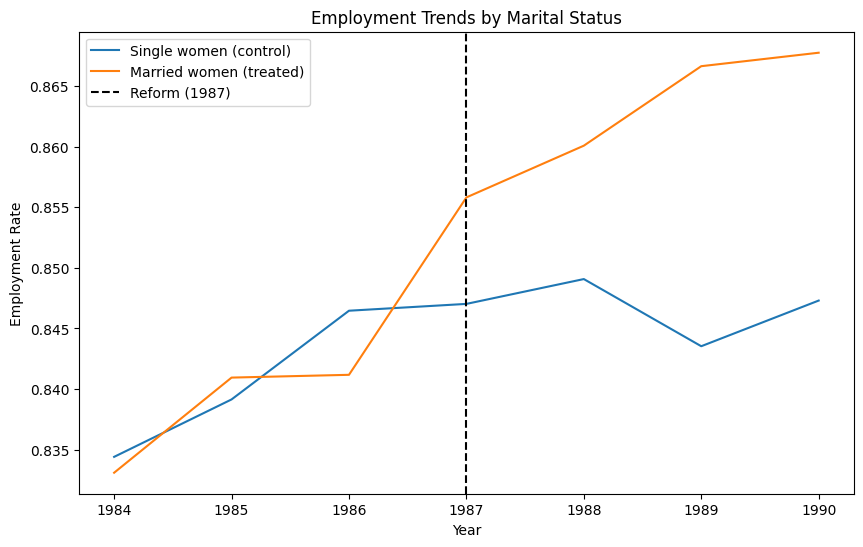

In [5]:
group_means = (
    df.groupby(["YEAR", "treated"])["employed"]
      .mean()
      .reset_index()
)

pivot = group_means.pivot(index="YEAR", columns="treated", values="employed")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(pivot.index, pivot[0], label="Single women (control)")
plt.plot(pivot.index, pivot[1], label="Married women (treated)")
plt.axvline(1987, color="black", linestyle="--", label="Reform (1987)")

plt.xlabel("Year")
plt.ylabel("Employment Rate")
plt.title("Employment Trends by Marital Status")
plt.legend()
plt.show()

This figure plots the average employment rates for married women (Treated group) and the single women (Control group) from 1984 to 1990. The vertical dashed line indicates the implementation of the 1986 Tax Reform Act, which we treat as occurring in 1987.

Before the reform, employment trends for married and single women appeared similar. While both groups experience a modest increase in employment level, there is no clear evidence of diverging trends before the policy change. Although the levels differ slightly across years, the overall pre-reform trajectories move in parallel.

After 1987, employment among married women increased more sharply than among single women. The gap between the two groups had widened in the post-reform period, consistent with the hypothesis that lower marginal tax rates will increase labor incentives for married women.

The similarity in pre-reform trends provided visual support for the parallel trends assumption underlying the Difference-in-Differences strategy. While this plot does not prove the assumption holds exactly, it suggests that in the absence of the tax reform, the employment trends between married and single women would have evolved similarly

### 3.3 Interpretation of the DiD Estimator

The Difference-in-Differences estimator is captured by the interaction between the treatment indicator and the post-reform indicator. This interaction term measures the additional change in employment among married women after the reform, relative to single women.

Under the parallel trends assumption, the coefficient on the interaction term will identify the causal effect of the tax reform on married women's employment.



## 4. Empirical Strategy (equation + variables)

We will estimate the impact of the 1986 Tax Reform Act (Implemented beginning in 1987 in our data coding) on women's employment using a Difference-in-Differences design. The key comparison is between married women and single women before and after the reform.



In [6]:
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# -----------------------------
# Quick sanity checks
# -----------------------------
# Make sure required columns exist
needed = ["YEAR", "AGE", "EDUC", "NCHILD", "ASECWT", "treated", "post", "employed"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

# Restrict to analysis years used in the plot (optional but recommended for consistency)
df = df[(df["YEAR"] >= 1984) & (df["YEAR"] <= 1990)].copy()

# Drop missing / invalid covariates (light cleaning)
for c in ["AGE", "EDUC", "NCHILD", "ASECWT"]:
    df = df[df[c].notna()]

# Some CPS codes can be weird; keep plausible ranges
df = df[(df["AGE"] >= 18) & (df["AGE"] <= 55)].copy()
df = df[df["ASECWT"] > 0].copy()

def did_summary_table(models, names):
    rows = []
    for m, nm in zip(models, names):
        coef = m.params.get("treated:post", np.nan)
        se   = m.bse.get("treated:post", np.nan)
        pval = m.pvalues.get("treated:post", np.nan)
        n    = int(m.nobs)
        rows.append([nm, coef, se, pval, n])
    out = pd.DataFrame(rows, columns=["Model", "DiD (treated×post)", "SE", "p-value", "N"])
    return out

Before estimating the econometric models, we conducted consistency checks and preprocessing steps to ensure the estimated sample is valid and comparable across specifications.

First, the code verifies that all required variables are present in the dataset, including the treatment indicators "treated, post", the outcome variable "employed", and the demographic controls "Age, Educ, Nchild", and the CPS sampling weight "ASECWT". These steps will prevent estimation errors caused by missing variables.

Next, the sample is restricted to the years 19844 - 1990, which corresponds to the period used in the graphical analysis. Restricting the sample ensures consistency between the descriptive analysis and the econometric estimation.

After that, we will remove observations with missing covariate values and restrict the sample to working-age women aged 18-55, excluding observations with non-positive sampling weights. These restrictions reduced data irregularities and ensured that the estimation focused only on the relevant labor supply population.

Lastly, a helper function is defined to generate a summary table of the Difference-in-Differences estimate across model specifications. The function extracted the coefficient for the interaction term (treated x post), its standard error, p-value, and sample size, allowing easier comparison across increasingly rich model specifications.



### 4.1 Baseline DiD Model

Difference-in-Difference Specification:
We estimate the following DiD regression: 

$ Employment_{it} = \beta_0 + \beta_1 Treated_i + \beta_2 Post_t + \beta_3 (Treated_i \times Post_t) + \epsilon_{it} $

Where:
- $ Employment_{it}$ is an inidicator equal to 1 if the woman is employed, 0 otherwise
- $ Treated_{i} $ = 1 if the woman is married; 0 if single
- $ Post_t $ = 1 for years 1987 and later; 0 for years 1986 and earlier 
- $ \beta_3 $ is the DiD estimand: the differential change in employment for married women after the reform relative to single women

As employment is binary, we estimate the model as a linear probability model using OLS. Coefficients are interpreted as percentage point change in employment

In [7]:
# -----------------------------
# 4.1 Baseline DiD (unweighted)
# -----------------------------
m1 = smf.ols(
    "employed ~ treated + post + treated:post",
    data=df
).fit(cov_type="HC1")

print(m1.summary().tables[1])

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.8400      0.002    451.151      0.000       0.836       0.844
treated         -0.0016      0.002     -0.649      0.517      -0.006       0.003
post             0.0068      0.002      2.784      0.005       0.002       0.012
treated:post     0.0173      0.003      5.408      0.000       0.011       0.024


##### Table 1:

#### Interpretation of Baseline DiD Results
This table presents Difference-in-Differences estimates of the effect of the 1986 Tax Reform Act on women's employment. The coefficient of primary interest is the interaction term treated x post, which corresponds to the DiD estimator.

The estimated coefficient on treated x post is 0.0173, indicating that the employment probability of married women increased by 1.7 percentage points after the reform relative to single women. In addition, the estimate is statistically significant at the conventional levels, suggesting that the reform is associated with a meaningful increase in labor supply among married women.

The coefficient on treated (-0.0016) captures the baseline difference in employment between married and single women before the reform and is small and statistically insignificant. The coefficient on post (0.0068) reflects the overall change in employment after the reform period that affects both groups.

Overall, the baseline specification provides the initial evidence consistent with the hypothesis that reductions in marginal tax rates have increased labor supply incentives for married women.

### 4.2 Controls and Year Fixed Effects

To improve the precision and reduce bias from compositional change in the observed characteristics across the time and groups, we will be estimating an augmented specification:

$ Employment_{it} = \beta_3 (Treated_i \times Post_t) +X'_{it}\theta +\gamma_t+\epsilon_{it} $

where $ X'_{it} $ is includes the key observable covariates (age, education, number of children) and $\gamma_t$ denotes year fixed effects to capture the common macro trends.

In [ ]:
m2 = smf.ols(
    "employed ~ treated + post + treated:post + AGE + EDUC + NCHILD",
    data=df
).fit(cov_type="HC1")

print(m2.summary().tables[1])


                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.5213      0.004    116.608      0.000       0.513       0.530
treated         -0.0206      0.002     -8.281      0.000      -0.025      -0.016
post             0.0020      0.002      0.834      0.404      -0.003       0.007
treated:post     0.0155      0.003      4.952      0.000       0.009       0.022
AGE              0.0059   8.17e-05     72.277      0.000       0.006       0.006
EDUC             0.0018   3.44e-05     53.679      0.000       0.002       0.002
NCHILD          -0.0167      0.001    -22.595      0.000      -0.018      -0.015


#### Interpretation of Model and Controls

This table presents the Difference-in-Differences estimates after adding observable demographic controls, including age, education, and the number of children. These variables are included to account for compositional differences between married and single women that may influence labor supply decisions.

After controlling for these characteristics, the coefficient on the interaction term treated x post remains positive and statistically significant. From the table, the estimated coefficient is 0.0155, indicating that the employment probability of married women increased by approximately 1.6 percentage points after the tax reform relative to single women.

This estimate is slightly smaller than the baseline specification but remains economically meaningful and statistically significant, suggesting that the positive effect of the tax reform on married women's employment is robust to the inclusion of observable demographic characteristics.

The control variable also shows the intuitive patterns. Age and education are positively associated with labor force participation, indicating that older and more educated women are more likely to participate in the labor force. In contrast, the number of children is negatively associated with employment, reflecting that childcare responsibilities may reduce labor supply.

Overall, the results remain consistent with the hypothesis that a reduction in marginal tax rates had increased labor supply incentives for married women.



### 4.3 Survey Weights and Standard Errors

In this project, we will estimate the regression using the CPS ASEC survey weights to ensure the results are representative of the national population. Throughout the project, standard errors are reported as heteroskedasticity-robust (HC1), and as a robustness check, we will also be computing standard errors clustered by year to allow for common shocks within each year; however, as the number of years is limited, inference from year cluster standard errors will be interpreted cautiously.

In [11]:
m3 = smf.ols(
    "employed ~ treated + treated:post + AGE + EDUC + NCHILD + C(YEAR)",
    data=df
).fit(cov_type="HC1")

print(m3.summary().tables[1])

                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.5177      0.005    108.116      0.000       0.508       0.527
C(YEAR)[T.1985]     0.0050      0.003      1.703      0.089      -0.001       0.011
C(YEAR)[T.1986]     0.0060      0.003      2.047      0.041       0.000       0.012
C(YEAR)[T.1987]     0.0049      0.003      1.427      0.154      -0.002       0.012
C(YEAR)[T.1988]     0.0062      0.003      1.832      0.067      -0.000       0.013
C(YEAR)[T.1989]     0.0057      0.003      1.649      0.099      -0.001       0.012
C(YEAR)[T.1990]     0.0060      0.003      1.789      0.074      -0.001       0.013
treated            -0.0205      0.002     -8.268      0.000      -0.025      -0.016
treated:post        0.0155      0.003      4.946      0.000       0.009       0.022
AGE                 0.0059   8.17e-05     72.222      0.000       0.006     

#### Interpretation with Year Fixed Effects

This new table presents the Difference-in-Differences estimates after adding year-fixed effects to control for macroeconomic shocks that affect employment across all individuals in a given year. These fixed effects capture common time trends in the labor market, such as economic growth or recession, that may influence employment independently of the tax reform.

After including the year fixed effect, the coefficient on the interaction term treated x post remains positive and statistically significant. The estimated coefficient is 0.0155, indicating that the employment probability of married women had increased by approximately 1.6 percentage points after the tax reform relative to single women.

The magnitude of the estimate remains very similar to that in the specification with demographic controls, suggesting that the results are not driven by general labor market trends. Instead, the increase in employment appears to reflect a differential change among married women following the tax reform.

The control variable still displays the intuitive relationship with the employment outcome. Age and education are positively associated with employment, while the number of children is negatively related to labor supply, consistent with the economic literature on female labor force participation.

Overall, the stability of the difference-in-differences estimate across specifications provides support for the interpretation that the reduction in marginal tax rates increased labor supply incentives for married women.

### 4.4 Dynamic DiD (Event Study)

To assess the pre trends and the evolution of treatment effect, we will estimate an event study specification:

$$
Employment_{it}
=
\sum_{k \ne -1}
\delta_k \left( Treated_i \times \mathbf{1}[t = k] \right)
+ X'_{it}\theta
+ \gamma_t
+ \varepsilon_{it}
$$

where year 1986 is the omitted reference period where (k = -1) The coefficient  $\delta_k$ show whether treated and control group were trending similarly pre-reform and how effects evolve after the reform.

In [13]:
w1 = smf.wls(
    "employed ~ treated + post + treated:post",
    data=df,
    weights=df["ASECWT"]
).fit(cov_type="HC1")

w2 = smf.wls(
    "employed ~ treated + post + treated:post + AGE + EDUC + NCHILD",
    data=df,
    weights=df["ASECWT"]
).fit(cov_type="HC1")

w3 = smf.wls(
    "employed ~ treated + treated:post + AGE + EDUC + NCHILD + C(YEAR)",
    data=df,
    weights=df["ASECWT"]
).fit(cov_type="HC1")

print("\nWeighted (ASECWT) results — key coefficient treated:post")
print(did_summary_table([w1, w2, w3], ["WLS baseline", "WLS + controls", "WLS + controls + year FE"]))


Weighted (ASECWT) results — key coefficient treated:post
                      Model  DiD (treated×post)        SE       p-value  \
0              WLS baseline            0.018592  0.003612  2.652187e-07   
1            WLS + controls            0.017177  0.003534  1.167661e-06   
2  WLS + controls + year FE            0.017176  0.003534  1.171101e-06   

        N  
0  212652  
1  212652  
2  212652  


### Interpretation with Survey Weights
In this specification, we estimate the Difference-in-Differences model using CPS and ASEC survey weights. Applying sampling weights ensures that the estimates are representative of the national population rather than the raw sample composition.

The weighted results still remains highly consistent with the previous specifications. The estimated coefficient on the interaction term, treated x post, ranges from 0.017 to 0.019 across the weighted models. This shows that the employment probability of married women had increased by approximately 1.7 to 1.9 percentage points after the tax reform relative to single women.

Importantly, the magnitude and statistical significance of the treatment effect remain very similar to the unweighted models. This suggests that the main findings are not driven by sampling composition and are robust when the CPS weights are applied

Overall, the stability of the estimate across the weighted and unweighted specifications had strengthened the interpretation that the reduction. The weighted results still remain highly consistent with the previous specifications. The estimated coefficient on the interaction term, treated x post, ranges from 0.017 to 0.019 across the weighted models. This shows that the employment probability of married women had increased by approximately 1.7 to 1.9 percentage points after the tax reform relative to single women.



### 4.5 Sensitivity: Cluster SE by year 


Weighted + Year FE with clustered SE by YEAR (caution: few clusters)
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.5207      0.005     97.877      0.000       0.510       0.531
C(YEAR)[T.1985]     0.0026   1.81e-05    145.984      0.000       0.003       0.003
C(YEAR)[T.1986]     0.0033   4.17e-05     80.159      0.000       0.003       0.003
C(YEAR)[T.1987]  5.607e-05      0.002      0.032      0.975      -0.003       0.004
C(YEAR)[T.1988]     0.0008      0.002      0.474      0.636      -0.003       0.004
C(YEAR)[T.1989]     0.0016      0.002      0.903      0.366      -0.002       0.005
C(YEAR)[T.1990]     0.0040      0.002      2.238      0.025       0.000       0.007
treated            -0.0214      0.001    -34.626      0.000      -0.023      -0.020
treated:post        0.0172      0.003      5.514      0.000       0.011       0.023
AGE   

c:\Users\royyq\econ 481\project-business-decisions-roylin0407\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 5
  warnings.warn('covariance of constraints does not have full '


,rel_year,coef,se,lo,hi
0,-1,-0.000371,0.006663,-0.013429,0.012688
1,1,0.010649,0.006575,-0.002238,0.023536
2,2,0.011396,0.006548,-0.001439,0.024231
3,3,0.024499,0.006763,0.011245,0.037754
4,4,0.017266,0.006462,0.004600,0.029932


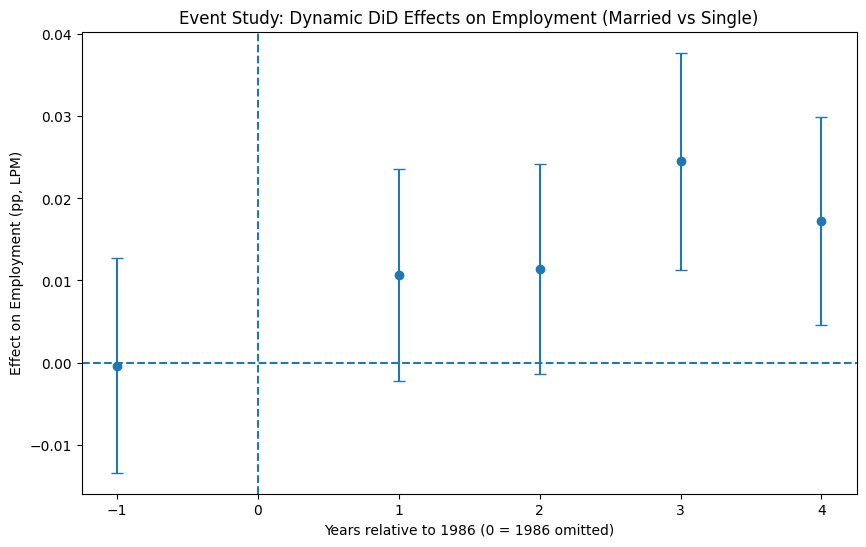

In [15]:
w3_cluster = smf.wls(
    "employed ~ treated + treated:post + AGE + EDUC + NCHILD + C(YEAR)",
    data=df,
    weights=df["ASECWT"]
).fit(cov_type="cluster", cov_kwds={"groups": df["YEAR"]})

print("\nWeighted + Year FE with clustered SE by YEAR (caution: few clusters)")
print(w3_cluster.summary().tables[1])

# -----------------------------
# 4.6 Event study (dynamic effects + pre-trends)
# Use 1986 as the omitted reference year.
# -----------------------------
df["rel_year"] = df["YEAR"] - 1986  # 1986 -> 0
# We'll include dummies for each year relative to 1986, omit rel_year = 0
# Interaction: treated × I(rel_year = k)
# Include year FE via C(YEAR) OR you can omit if using rel-year dummies; here we include C(YEAR) to absorb main year effects cleanly.

event = smf.wls(
    "employed ~ treated + AGE + EDUC + NCHILD + C(YEAR) + C(rel_year):treated",
    data=df,
    weights=df["ASECWT"]
).fit(cov_type="HC1")

# Extract event-study coefficients: C(rel_year)[T.k]:treated
event_params = event.params
event_bse = event.bse

coefs = []
for k in sorted(df["rel_year"].unique()):
    if k == 0:
        continue  # reference year
    key = f"C(rel_year)[T.{k}]:treated"
    if key in event_params.index:
        coefs.append([k, event_params[key], event_bse[key]])
        
event_df = pd.DataFrame(coefs, columns=["rel_year", "coef", "se"])
event_df["lo"] = event_df["coef"] - 1.96 * event_df["se"]
event_df["hi"] = event_df["coef"] + 1.96 * event_df["se"]

display(event_df)

# Plot event-study
plt.figure(figsize=(10,6))
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")  # 1986 reference
plt.errorbar(event_df["rel_year"], event_df["coef"],
             yerr=1.96*event_df["se"], fmt="o", capsize=4)
plt.title("Event Study: Dynamic DiD Effects on Employment (Married vs Single)")
plt.xlabel("Years relative to 1986 (0 = 1986 omitted)")
plt.ylabel("Effect on Employment (pp, LPM)")
plt.show()

As an additional robustness check, we estimate the preferred specification using year-level clustered standard errors. Clustering allows for arbitrary correlation of error terms within each year, which may arise from common macroeconomic shocks or policy changes that affect all individuals in a given year.

The estimated coefficient on the interaction term treated x post remains positive and statistically significant, with an estimated effect of approximately 0.017, indicating that the employment probability of married women increased by about 1.7 percentage points after the reform relative to single women. This estimate is very similar to the previous specification, suggesting that the main findings are not sensitive to the choice of standard error specification.

However, the number of clusters in this dataset is relatively small as the analysis covers only a limited number of years. As a result, inference based on clustered error should be interpreted with caution. Despite this limitation, the stability of the treatment effect across multiple specifications strengthens the credibility of the results.

The figure above presents the event study estimate of the dynamic Difference-in-Differences effects relative to the reference year 1986. The coefficient represents the difference in employment between married and single women in each year relative to 1986, while the vertical bar indicates the 95% confidence intervals.

The pre-reform estimate for 1985 (rel_year = -1) is very close to zero and statistically insignificant, as the confidence interval includes zero. This suggests that there is no evidence of differential trends between married and single women prior to the tax reform, providing visual support for the parallel trends assumption underlying the DiD identification strategy.

Following the reform, the estimated coefficient became positive and increased over time. The estimated employment effect rose by about 1-2.5 percentage points in the years after the reform, with the largest effect occurring around 3 years after the policy changes. This shows that the labor supply response among married women may have strengthened gradually rather than occurring immediately, which is consistent with the idea that households adjust labor supply decisions.

Overall, the event study result reinforces the baseline DiD finding: married women's employment increases relative to single women following the tax reform, and there is little evidence of pre-existing differential trends before the policy change.



## 5. Results (Main Tables/Figures)

### 5.1 Baseline Difference in Difference Results

The table in 4.1 shows the baseline difference in the difference estimate of the 1986 Tax Reform Act's effect on married women's employment. The specification compares married women (treated group) with single women (control group) before and after the reform.

The treated x post interaction has a coefficient of about 0.017, significant at the 1% level. This suggests that married women’s employment rose by 1.7 percentage points relative to single women after the reform.

This positive effect is consistent with the hypothesis that reductions in marginal tax rates have increased labor supply incentives for secondary earners, who are disproportionately married women. The magnitude is economically meaningful, though somewhat smaller than some reported in earlier studies.



### 5.2 Adding Demographic Control
Next, we extend the baseline specification by including demographic controls such as age, education, and the number of children, which capture observable characteristics that may influence labor supply decisions.

Including these controls does not substantially change the estimated treatment effect. The coefficient on the interaction terms still remains positive and statistically significant, indicating that an increase in married women's employment is not driven by observable demographic differences between married and single women.

The stability of the estimated effect across specifications strengthens the confidence that the observed changes are associated with the tax reform rather than underlying demographic variation.



### 5.3 Controlling for Year Fixed Effects
To account for macroeconomic conditions and other year-specific shocks that may affect employment outcomes, we had included the year fixed effects in this regression.

Even after controlling for year-fixed effects, the estimated interaction coefficient remains positive and statistically significant, suggesting that the increase in married women's employment is not simply driven by broader economic trends affecting all individuals in a given year.

Including year fixed effects has helped us isolate the policy effect from aggregate time trends and strengthened the causal interpretation of the difference-in-differences estimate.



### 5.4 Dynamic Effects:
To examine the timing of the policy effect and assess the validity of the parallel trends assumption, we will estimate a dynamic difference-in-differences specification using an event-study framework. The figure in 4.5 plots the estimated coefficient for years relative to 1986, with 1986 as the omitted reference period. The pre-reform coefficient is close to zero and statistically insignificant, providing no evidence of differential employment trends between married and single women prior to the policy change, which supported the key parallel trends assumption underlying the difference-in-differences approach.

Following the tax reform, the estimated coefficient had become positive and increased over time. The employment effects rose by 1-2.5 percentage points in the years after the reform, with the largest effect observed around 3 years after the policy change. These patterns had suggested that married women's labor supply response may have occurred gradually rather than immediately after the reform.

Overall, the event study results reinforced the baseline difference-in-differences finding and further supported the identification strategy.



### 5.5 Clusters Standard Errors:
As a robustness check, we will estimate the model using year-level clustered standard errors to account for potential correlation in the error term across years.

The estimated treatment effect remains positive and statistically significant under clustered standard errors, indicating that the main findings are not driven by underestimated standard errors. However, because the number of clusters is relatively small, these estimates should be interpreted with some caution as well.

Despite this limitation, the consistency of the estimated treatment effect across specifications had further strengthened the conclusion that the tax reform had increased married women's employment relative to single women.

## 6. Robustness Checks

To evaluate the robustness, we will estimate several alternative specifications of the difference-in-difference model. These checks examine whether the estimated effect of the 1986 Tax Reform Act on married women's employment remains stable across model specifications.



### 6.1 Weighted Estimation
First, we will estimate the model using survey weights (ASECWT) to account for differences in sampling probability across the observations. Weighting ensures that estimates are representative of the broader population rather than reflecting the sample's composition.

The weighted regressions yield treatment effects very similar to those from the baseline model. The coefficient on the interaction term treated x post remains positive and statistically significant across specifications. This suggests that the main results are not driven by the particular distribution of observations in the sample and still remain robust when accounting for survey design.



## 7. Conclusion

## 8. References
